# 🚢 Project 1: Portfolio Project Walkthrough — Kaggle Titanic

**Objective:** Build a predictive model to determine which passengers survived the Titanic disaster.

**Skills Covered:**
- Data Cleaning & Preprocessing
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Machine Learning Classification Models
- Model Evaluation

**Libraries Used:** pandas, numpy, matplotlib, seaborn, scikit-learn

## Step 1: Install & Import Libraries

In [1]:
# Install required libraries (if not already installed)
!pip install pandas numpy matplotlib seaborn scikit-learn --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


## Step 2: Load the Titanic Dataset
> We load directly from the web (no Kaggle API key needed for Google Colab)

In [3]:
# Load Titanic dataset from public URL (seaborn's built-in dataset)
url_train = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url_train)

print(f'Dataset Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset Shape: (891, 12)
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Step 3: Exploratory Data Analysis (EDA)

In [4]:
# Basic dataset info
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
# Statistical summary
print('=== Statistical Summary ===')
df.describe()

=== Statistical Summary ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
# Missing values analysis
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('=== Missing Values ===')
print(missing_df[missing_df['Missing Count'] > 0])

=== Missing Values ===
          Missing Count  Missing %
Age                 177  19.865320
Cabin               687  77.104377
Embarked              2   0.224467


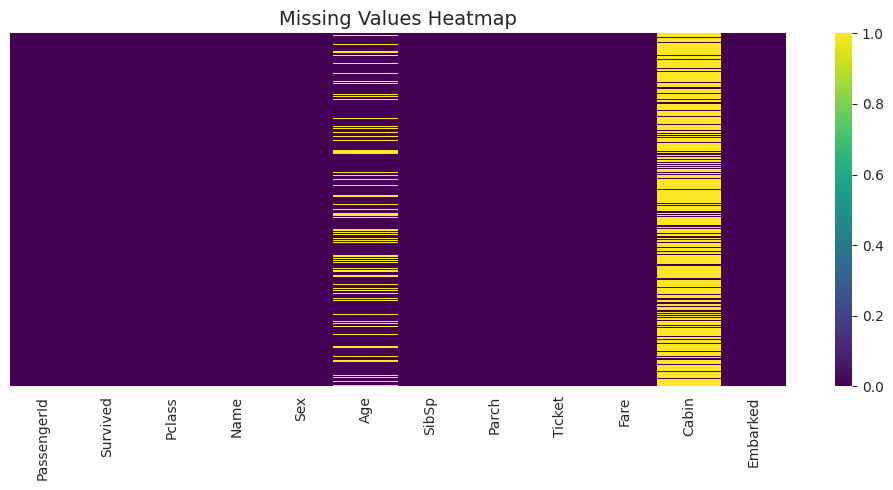

In [7]:
# Visualize missing values
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title('Missing Values Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

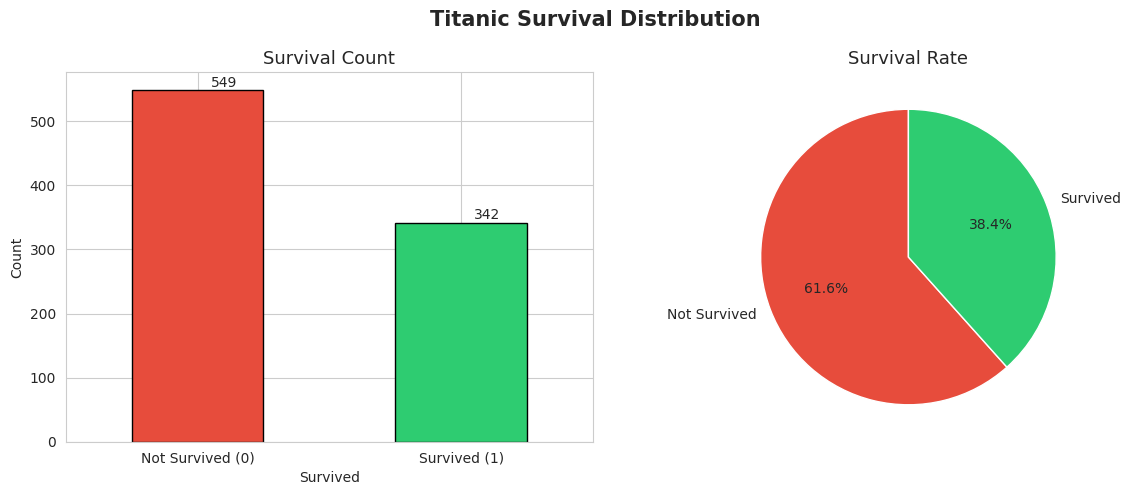

Survival Rate: 38.4%


In [8]:
# Survival distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
df['Survived'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Survival Count', fontsize=13)
axes[0].set_xticklabels(['Not Survived (0)', 'Survived (1)'], rotation=0)
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x()+0.3, p.get_height()+5))

# Pie chart
df['Survived'].value_counts().plot(kind='pie', ax=axes[1],
    labels=['Not Survived', 'Survived'], autopct='%1.1f%%',
    colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[1].set_title('Survival Rate', fontsize=13)
axes[1].set_ylabel('')

plt.suptitle('Titanic Survival Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Survival Rate: {df['Survived'].mean()*100:.1f}%")

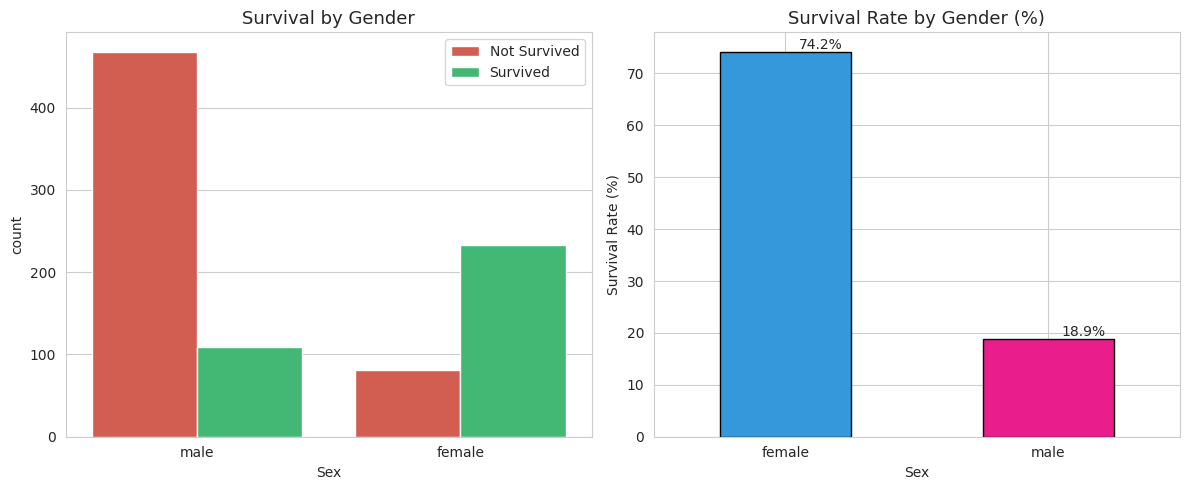

In [9]:
# Survival by Gender
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='Sex', hue='Survived', data=df, ax=axes[0],
              palette={0: '#e74c3c', 1: '#2ecc71'})
axes[0].set_title('Survival by Gender', fontsize=13)
axes[0].legend(['Not Survived', 'Survived'])

survival_rate_sex = df.groupby('Sex')['Survived'].mean() * 100
survival_rate_sex.plot(kind='bar', ax=axes[1], color=['#3498db', '#e91e8c'], edgecolor='black')
axes[1].set_title('Survival Rate by Gender (%)', fontsize=13)
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%', (p.get_x()+0.3, p.get_height()+0.5))

plt.tight_layout()
plt.show()

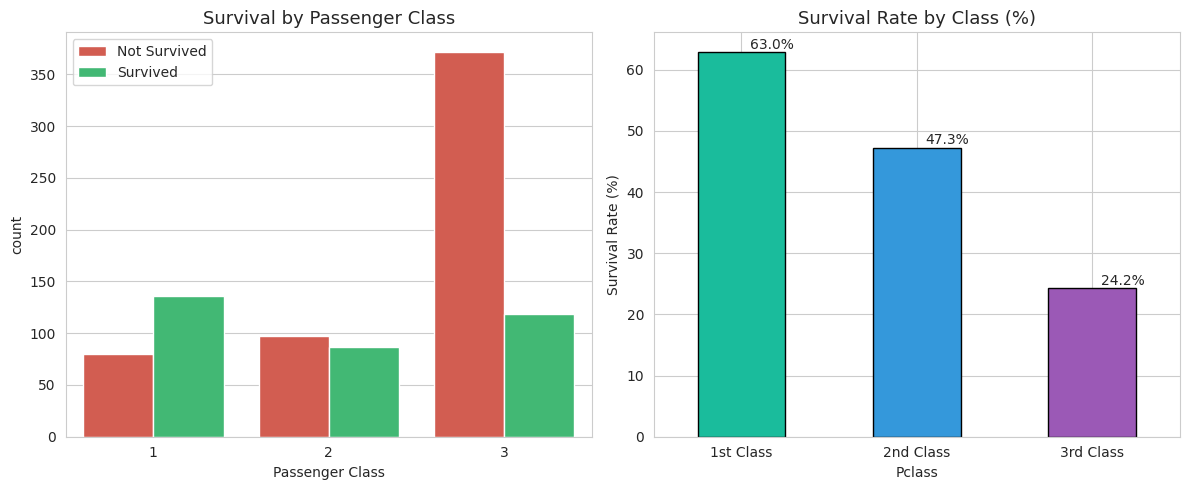

In [10]:
# Survival by Passenger Class
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='Pclass', hue='Survived', data=df, ax=axes[0],
              palette={0: '#e74c3c', 1: '#2ecc71'})
axes[0].set_title('Survival by Passenger Class', fontsize=13)
axes[0].set_xlabel('Passenger Class')
axes[0].legend(['Not Survived', 'Survived'])

survival_pclass = df.groupby('Pclass')['Survived'].mean() * 100
survival_pclass.plot(kind='bar', ax=axes[1], color=['#1abc9c', '#3498db', '#9b59b6'], edgecolor='black')
axes[1].set_title('Survival Rate by Class (%)', fontsize=13)
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_xticklabels(['1st Class', '2nd Class', '3rd Class'], rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%', (p.get_x()+0.3, p.get_height()+0.5))

plt.tight_layout()
plt.show()

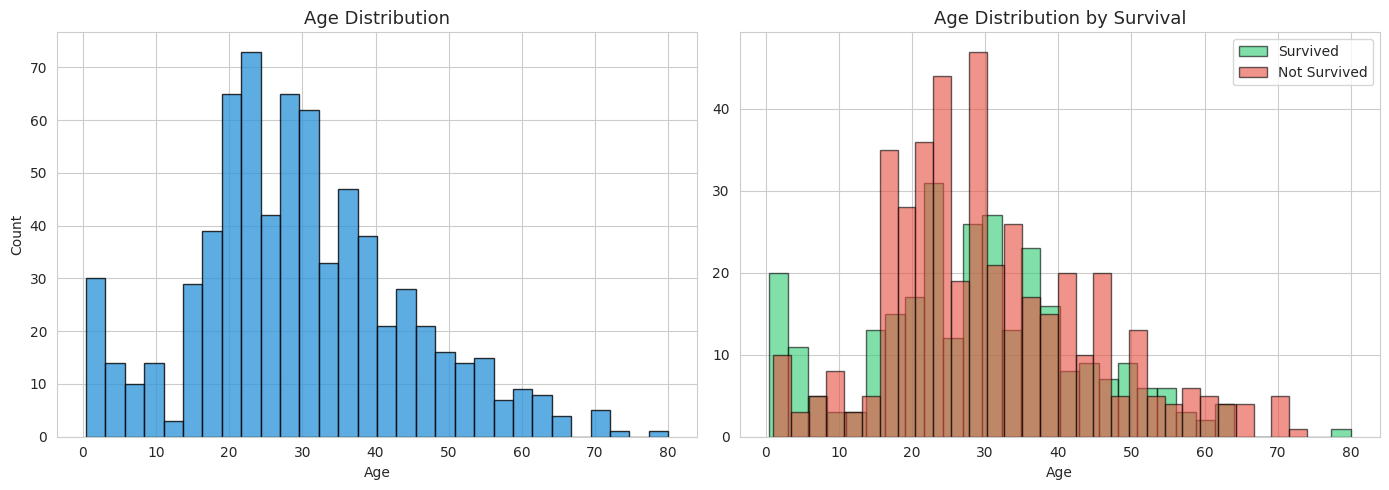

In [11]:
# Age distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Age'].dropna().hist(bins=30, ax=axes[0], color='#3498db', edgecolor='black', alpha=0.8)
axes[0].set_title('Age Distribution', fontsize=13)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

df[df['Survived']==1]['Age'].dropna().hist(bins=30, ax=axes[1], alpha=0.6, label='Survived', color='#2ecc71', edgecolor='black')
df[df['Survived']==0]['Age'].dropna().hist(bins=30, ax=axes[1], alpha=0.6, label='Not Survived', color='#e74c3c', edgecolor='black')
axes[1].set_title('Age Distribution by Survival', fontsize=13)
axes[1].set_xlabel('Age')
axes[1].legend()

plt.tight_layout()
plt.show()

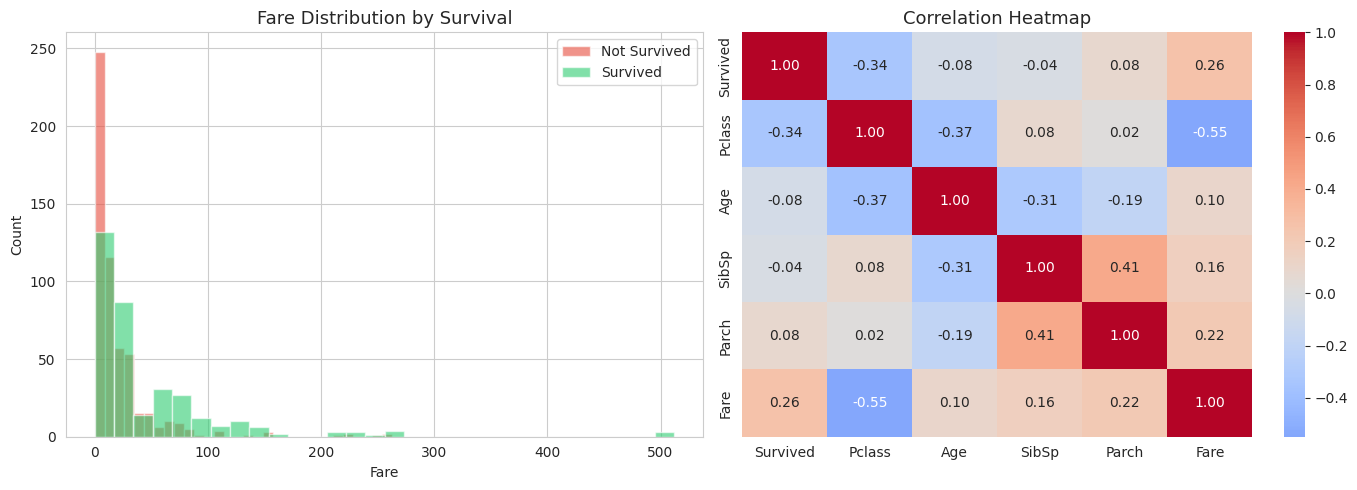

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming 'df' is already defined from previous cells

# Fare distribution and correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fare by survival
df[df['Survived'] == 0]['Fare'].hist(bins=30, ax=axes[0], alpha=0.6, label='Not Survived', color='#e74c3c')
df[df['Survived'] == 1]['Fare'].hist(bins=30, ax=axes[0], alpha=0.6, label='Survived', color='#2ecc71')
axes[0].set_title('Fare Distribution by Survival', fontsize=13)
axes[0].set_xlabel('Fare')
axes[0].set_ylabel('Count') # Added y-label for clarity
axes[0].legend()

# Correlation heatmap (numeric columns)
numeric_cols = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]
corr = numeric_cols.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1], center=0)
axes[1].set_title('Correlation Heatmap', fontsize=13)

plt.tight_layout()
plt.show()

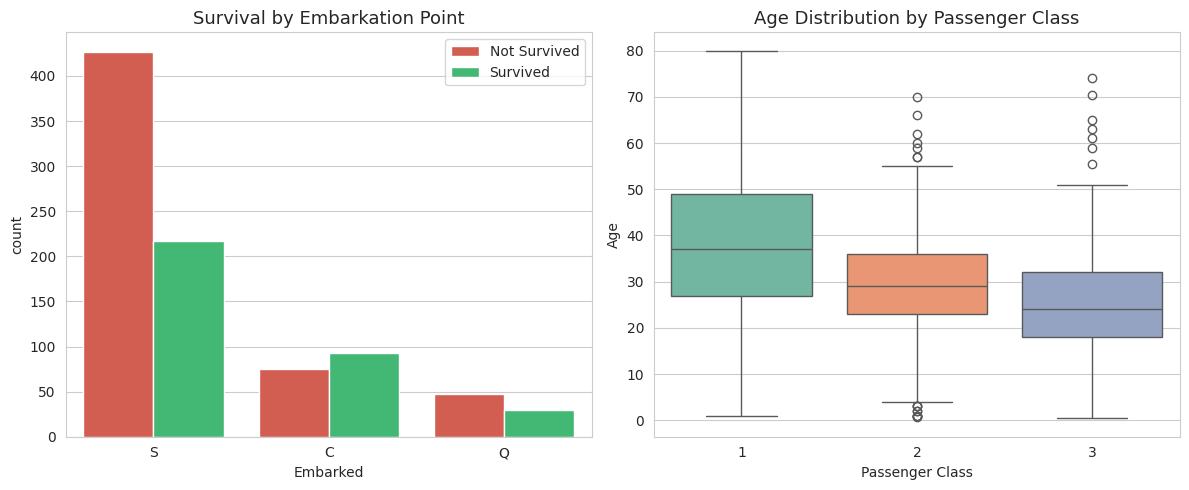

In [14]:
# Survival by embarkation point
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='Embarked', hue='Survived', data=df, ax=axes[0],
              palette={0: '#e74c3c', 1: '#2ecc71'})
axes[0].set_title('Survival by Embarkation Point', fontsize=13)
axes[0].legend(['Not Survived', 'Survived'])

# Age by class boxplot
sns.boxplot(x='Pclass', y='Age', data=df, ax=axes[1],
            palette='Set2', hue='Pclass', legend=False)
axes[1].set_title('Age Distribution by Passenger Class', fontsize=13)
axes[1].set_xlabel('Passenger Class')

plt.tight_layout()
plt.show()

## Step 4: Data Cleaning & Feature Engineering

In [15]:
# Work on a copy
df_clean = df.copy()

# --- Handle Missing Values ---

# 1. Age: fill with median age per Pclass and Sex
df_clean['Age'] = df_clean.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

# 2. Embarked: fill with mode
df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0], inplace=True)

# 3. Fare: fill with median
df_clean['Fare'].fillna(df_clean['Fare'].median(), inplace=True)

# 4. Drop Cabin (too many missing values ~77%)
df_clean.drop(columns=['Cabin'], inplace=True)

print('Missing values after cleaning:')
print(df_clean.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [16]:
# --- Feature Engineering ---

# 1. Extract Title from Name
df_clean['Title'] = df_clean['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
# Group rare titles
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr',
               'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df_clean['Title'] = df_clean['Title'].replace(rare_titles, 'Rare')
df_clean['Title'] = df_clean['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
print('Title value counts:')
print(df_clean['Title'].value_counts())

# 2. Family Size
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1

# 3. Is Alone
df_clean['IsAlone'] = (df_clean['FamilySize'] == 1).astype(int)

# 4. Age Bands
df_clean['AgeBand'] = pd.cut(df_clean['Age'], bins=[0, 12, 20, 40, 60, 100],
                             labels=['Child', 'Teenager', 'Adult', 'MiddleAge', 'Senior'])

# 5. Fare Bands
df_clean['FareBand'] = pd.qcut(df_clean['Fare'], 4, labels=[1, 2, 3, 4])

print('\nNew features created: Title, FamilySize, IsAlone, AgeBand, FareBand')
df_clean[['Title', 'FamilySize', 'IsAlone', 'AgeBand', 'FareBand']].head()

Title value counts:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

New features created: Title, FamilySize, IsAlone, AgeBand, FareBand


,Title,FamilySize,IsAlone,AgeBand,FareBand
0,Mr,2,0,Adult,1
1,Mrs,2,0,Adult,4
2,Miss,1,1,Adult,2
3,Mrs,2,0,Adult,4
4,Mr,1,1,Adult,2


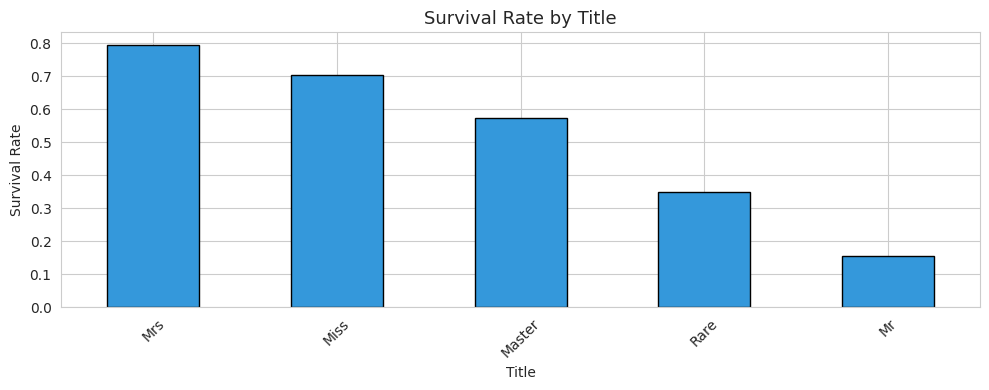

In [17]:
# Survival rate by Title
plt.figure(figsize=(10, 4))
title_survival = df_clean.groupby('Title')['Survived'].mean().sort_values(ascending=False)
title_survival.plot(kind='bar', color='#3498db', edgecolor='black')
plt.title('Survival Rate by Title', fontsize=13)
plt.ylabel('Survival Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

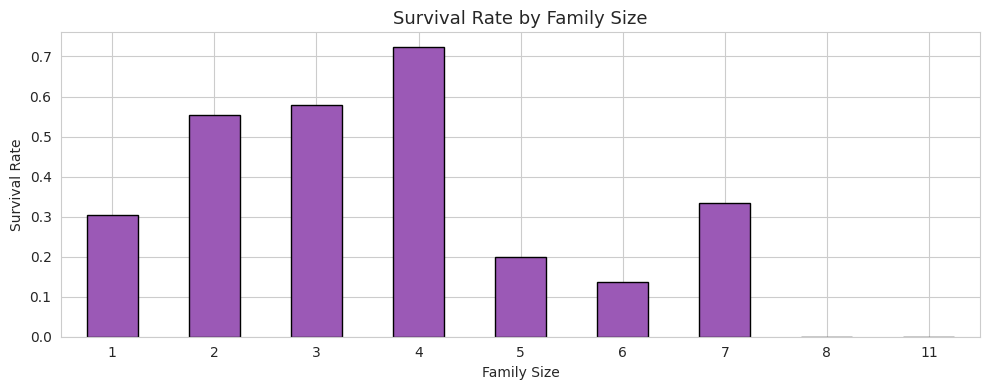

In [18]:
# Survival by Family Size
plt.figure(figsize=(10, 4))
family_survival = df_clean.groupby('FamilySize')['Survived'].mean()
family_survival.plot(kind='bar', color='#9b59b6', edgecolor='black')
plt.title('Survival Rate by Family Size', fontsize=13)
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 5: Encode Categorical Variables & Prepare Features

In [19]:
# Encode categorical columns
le = LabelEncoder()
df_clean['Sex_enc'] = le.fit_transform(df_clean['Sex'])          # female=0, male=1
df_clean['Embarked_enc'] = le.fit_transform(df_clean['Embarked']) # C=0, Q=1, S=2
df_clean['Title_enc'] = le.fit_transform(df_clean['Title'])
df_clean['AgeBand_enc'] = df_clean['AgeBand'].cat.codes
df_clean['FareBand_enc'] = df_clean['FareBand'].astype(int)

# Select features for modeling
features = ['Pclass', 'Sex_enc', 'Age', 'SibSp', 'Parch', 'Fare',
            'Embarked_enc', 'Title_enc', 'FamilySize', 'IsAlone',
            'AgeBand_enc', 'FareBand_enc']

X = df_clean[features]
y = df_clean['Survived']

print(f'Feature matrix shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'\nSelected Features: {features}')

Feature matrix shape: (891, 12)
Target shape: (891,)

Selected Features: ['Pclass', 'Sex_enc', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_enc', 'Title_enc', 'FamilySize', 'IsAlone', 'AgeBand_enc', 'FareBand_enc']


In [20]:
# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')

Training set: 712 samples
Test set:     179 samples


## Step 6: Train Multiple ML Models

In [21]:
# Define models
models = {
    'Logistic Regression':      LogisticRegression(max_iter=500, random_state=42),
    'Decision Tree':            DecisionTreeClassifier(random_state=42),
    'Random Forest':            RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':        GradientBoostingClassifier(random_state=42),
    'SVM':                      SVC(probability=True, random_state=42),
    'K-Nearest Neighbors':      KNeighborsClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred  = model.predict(X_test_scaled)
    y_prob  = model.predict_proba(X_test_scaled)[:, 1]
    acc     = accuracy_score(y_test, y_pred)
    auc     = roc_auc_score(y_test, y_prob)
    cv_acc  = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
    results[name] = {'Accuracy': acc, 'ROC-AUC': auc, 'CV Accuracy': cv_acc}
    print(f'{name:<25} | Accuracy: {acc:.4f} | ROC-AUC: {auc:.4f} | CV Acc: {cv_acc:.4f}')

print('\n✅ All models trained!')

Logistic Regression       | Accuracy: 0.8156 | ROC-AUC: 0.8556 | CV Acc: 0.7936
Decision Tree             | Accuracy: 0.8101 | ROC-AUC: 0.7885 | CV Acc: 0.7683
Random Forest             | Accuracy: 0.7989 | ROC-AUC: 0.8179 | CV Acc: 0.7964
Gradient Boosting         | Accuracy: 0.8045 | ROC-AUC: 0.8437 | CV Acc: 0.8133
SVM                       | Accuracy: 0.8380 | ROC-AUC: 0.8628 | CV Acc: 0.8245
K-Nearest Neighbors       | Accuracy: 0.8101 | ROC-AUC: 0.8279 | CV Acc: 0.8091

✅ All models trained!


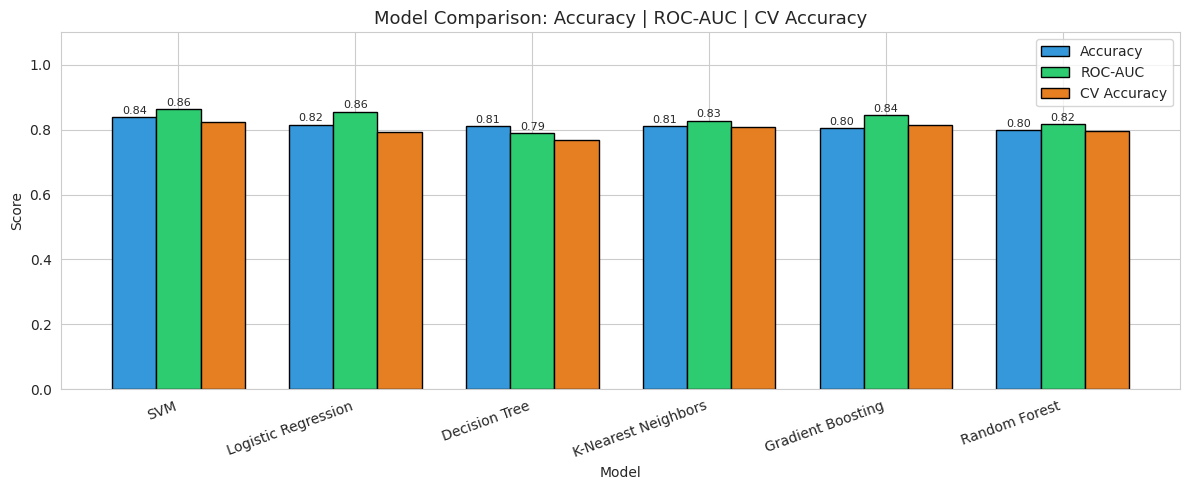


Model Rankings:
                     Accuracy   ROC-AUC  CV Accuracy
SVM                  0.837989  0.862846     0.824466
Logistic Regression  0.815642  0.855599     0.793618
Decision Tree        0.810056  0.788538     0.768315
K-Nearest Neighbors  0.810056  0.827866     0.809061
Gradient Boosting    0.804469  0.843742     0.813316
Random Forest        0.798883  0.817918     0.796435


In [22]:
# Model comparison bar chart
results_df = pd.DataFrame(results).T.sort_values('Accuracy', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(results_df))
width = 0.25

bars1 = ax.bar(x - width, results_df['Accuracy'],  width, label='Accuracy',    color='#3498db', edgecolor='black')
bars2 = ax.bar(x,          results_df['ROC-AUC'],  width, label='ROC-AUC',     color='#2ecc71', edgecolor='black')
bars3 = ax.bar(x + width,  results_df['CV Accuracy'], width, label='CV Accuracy', color='#e67e22', edgecolor='black')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Accuracy | ROC-AUC | CV Accuracy', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=20, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)

for bar in bars1: ax.annotate(f'{bar.get_height():.2f}', (bar.get_x()+bar.get_width()/2, bar.get_height()+0.01), ha='center', fontsize=8)
for bar in bars2: ax.annotate(f'{bar.get_height():.2f}', (bar.get_x()+bar.get_width()/2, bar.get_height()+0.01), ha='center', fontsize=8)

plt.tight_layout()
plt.show()
print('\nModel Rankings:')
print(results_df)

## Step 7: Tune Best Model (Random Forest) with GridSearchCV

In [24]:
# Hyperparameter tuning for Random Forest
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

print(f'\nBest Parameters: {grid_search.best_params_}')
print(f'Best CV Accuracy: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300}
Best CV Accuracy: 0.8259


In [25]:
# Evaluate best model
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test_scaled)
y_prob_best = best_rf.predict_proba(X_test_scaled)[:, 1]

print('=== Best Random Forest — Final Evaluation ===')
print(f'Test Accuracy : {accuracy_score(y_test, y_pred_best):.4f}')
print(f'ROC-AUC Score : {roc_auc_score(y_test, y_prob_best):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_best, target_names=['Not Survived', 'Survived']))

=== Best Random Forest — Final Evaluation ===
Test Accuracy : 0.8156
ROC-AUC Score : 0.8430

Classification Report:
              precision    recall  f1-score   support

Not Survived       0.82      0.89      0.86       110
    Survived       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179



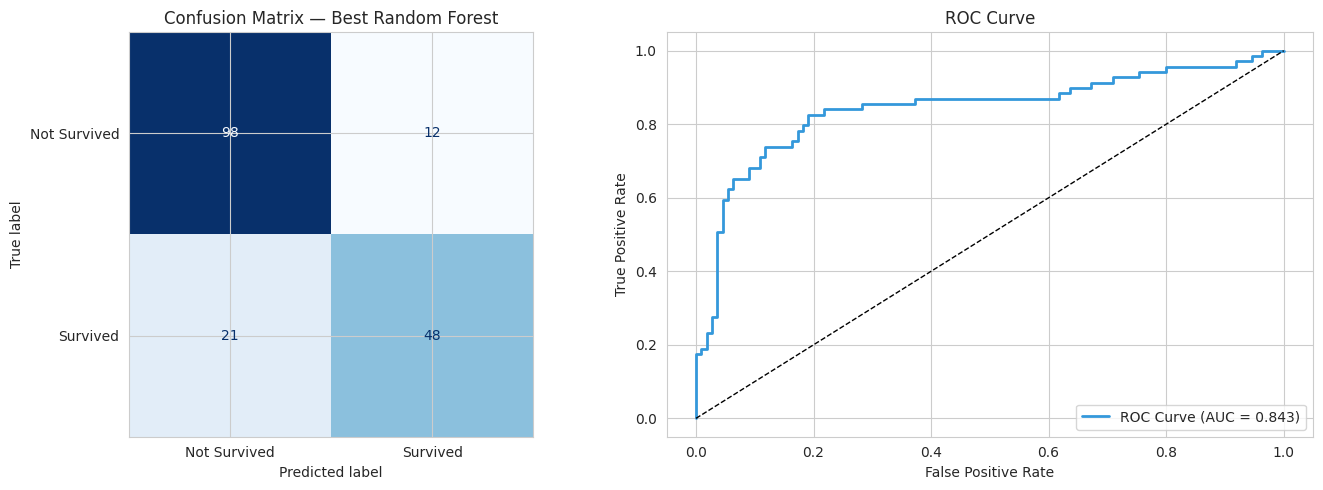

In [26]:
# Confusion Matrix & ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Survived', 'Survived'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix — Best Random Forest', fontsize=12)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
auc_score = roc_auc_score(y_test, y_prob_best)
axes[1].plot(fpr, tpr, color='#3498db', lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=12)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

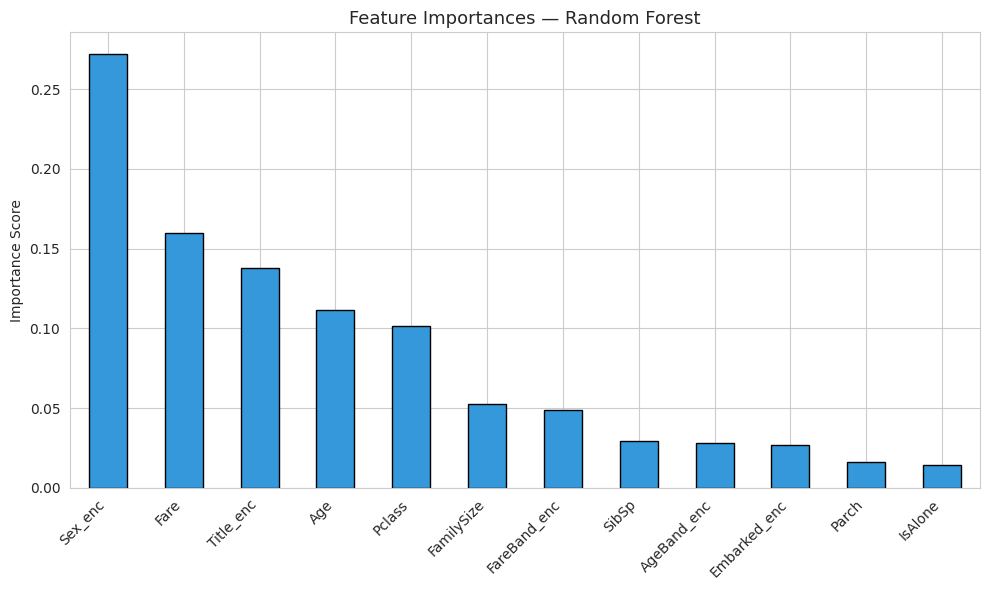


Top 5 Most Important Features:
Sex_enc      0.272004
Fare         0.160020
Title_enc    0.138050
Age          0.111715
Pclass       0.101448
dtype: float64


In [27]:
# Feature Importance
importance = pd.Series(best_rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importance.plot(kind='bar', color='#3498db', edgecolor='black')
plt.title('Feature Importances — Random Forest', fontsize=13)
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nTop 5 Most Important Features:')
print(importance.head())

## Step 8: ROC Curves for All Models

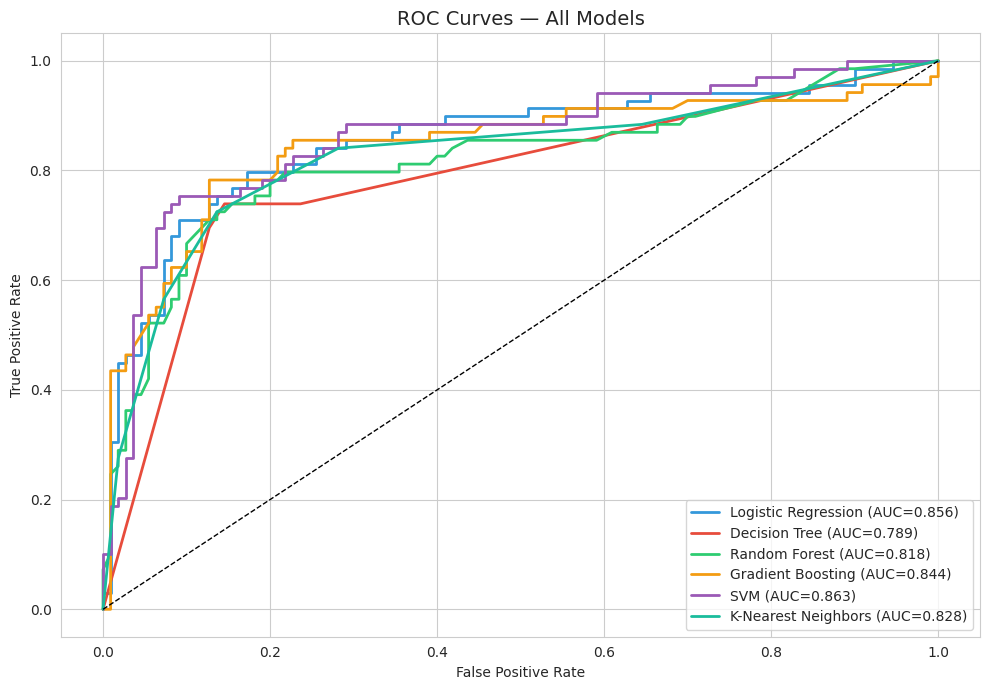

In [28]:
plt.figure(figsize=(10, 7))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for (name, model), color in zip(models.items(), colors):
    model.fit(X_train_scaled, y_train)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models', fontsize=14)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Step 9: Summary & Conclusions

In [29]:
print('=' * 60)
print('     TITANIC SURVIVAL PREDICTION — FINAL SUMMARY')
print('=' * 60)

print('\n📊 Key EDA Findings:')
print(f'  • Overall survival rate: {df["Survived"].mean()*100:.1f}%')
female_surv = df[df['Sex']=='female']['Survived'].mean()*100
male_surv   = df[df['Sex']=='male']['Survived'].mean()*100
print(f'  • Female survival rate : {female_surv:.1f}%')
print(f'  • Male survival rate   : {male_surv:.1f}%')
for cls in [1, 2, 3]:
    r = df[df['Pclass']==cls]['Survived'].mean()*100
    print(f'  • Class {cls} survival rate: {r:.1f}%')

print('\n🤖 Best Model Performance:')
best_acc = accuracy_score(y_test, y_pred_best)
best_auc = roc_auc_score(y_test, y_prob_best)
print(f'  • Model    : Tuned Random Forest')
print(f'  • Accuracy : {best_acc:.4f} ({best_acc*100:.1f}%)')
print(f'  • ROC-AUC  : {best_auc:.4f}')

print('\n🔑 Top 3 Survival Predictors:')
top3 = importance.head(3)
for feat, imp in top3.items():
    print(f'  • {feat}: {imp:.4f}')

print('\n✅ Project Complete!')

     TITANIC SURVIVAL PREDICTION — FINAL SUMMARY

📊 Key EDA Findings:
  • Overall survival rate: 38.4%
  • Female survival rate : 74.2%
  • Male survival rate   : 18.9%
  • Class 1 survival rate: 63.0%
  • Class 2 survival rate: 47.3%
  • Class 3 survival rate: 24.2%

🤖 Best Model Performance:
  • Model    : Tuned Random Forest
  • Accuracy : 0.8156 (81.6%)
  • ROC-AUC  : 0.8430

🔑 Top 3 Survival Predictors:
  • Sex_enc: 0.2720
  • Fare: 0.1600
  • Title_enc: 0.1381

✅ Project Complete!
